In [13]:
!pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.datasets import load_iris

In [15]:
data=load_iris()
x=data.data[:,:2]
y=data.target

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
scale=StandardScaler()
x_train=scale.fit_transform(x_train)
x_test=scale.transform(x_test)

In [34]:
def plot_boundary(model,x,y,title):
    h=0.02
    x_min,x_max=x[:,0].min()-1,x[:,0].max()+1
    y_min,y_max=x[:,0].min()-1,x[:,0].max()+1

    xx,yy=np.meshgrid(
        np.arange(x_min,x_max,h),
        np.arange(y_min,y_max,h)
    )
    z=model.predict(np.c_[xx.ravel(),yy.ravel()])
    z=z.reshape(xx.shape)

    plt.contourf(xx,yy,z,alpha=0.3)
    plt.scatter(x[:,0],x[:,1],c=y,edgecolor='k')

    # Plot Support Vector
    plt.scatter(model.support_vectors_[:,0],
               model.support_vectors_[:,1],
               s=100,facecolor='none',edgecolor='black')
    plt.title(title)
    plt.xlabel("Feature label1")
    plt.ylabel("Feature lable2")
    plt.show()

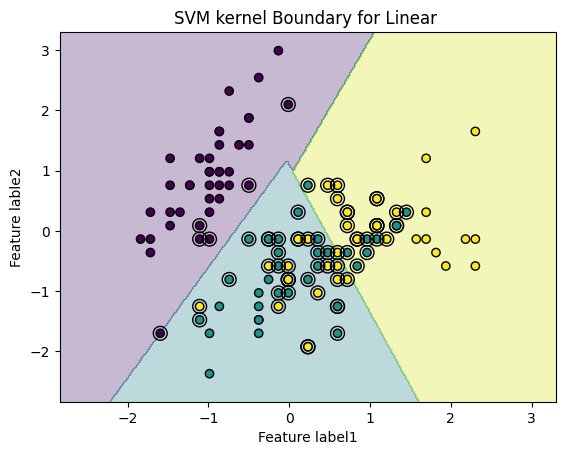

In [35]:
svm_kernel=SVC(kernel='linear')
svm_kernel.fit(x_train,y_train)
plot_boundary(svm_kernel,x_train,y_train,"SVM kernel Boundary for Linear ")

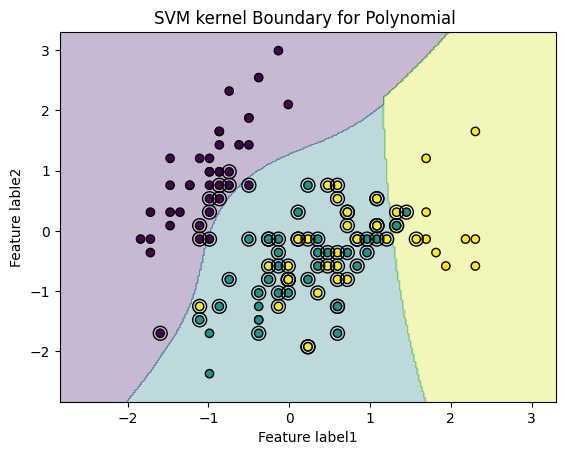

In [41]:
svm_kernel_poly=SVC(kernel='poly')
svm_kernel_poly.fit(x_train,y_train)
plot_boundary(svm_kernel_poly,x_train,y_train,"SVM kernel Boundary for Polynomial ")

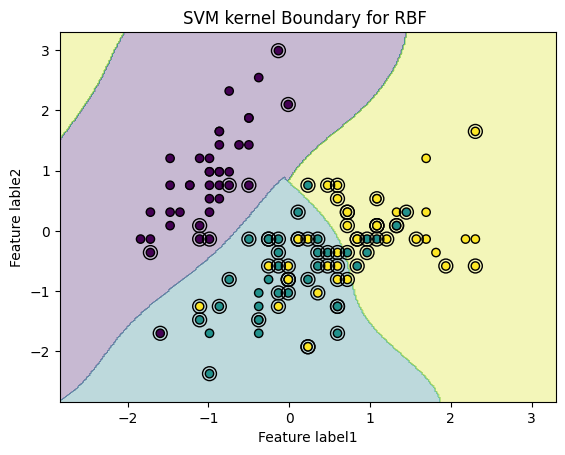

In [39]:
svm_kernel_rbf=SVC(kernel='rbf')
svm_kernel_rbf.fit(x_train,y_train)
plot_boundary(svm_kernel_rbf,x_train,y_train,"SVM kernel Boundary for RBF ")